<a href="https://colab.research.google.com/github/pendulumswings/pendulumswings.github.io/blob/main/scripts/chapter3/small_mass_hanging_motion_large_period.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Radial oscillation period of  $m$ under large oscillations of $m_{2}$. Comparison with Radial oscillation period of  $m$ under small oscillations of $m_{2}$

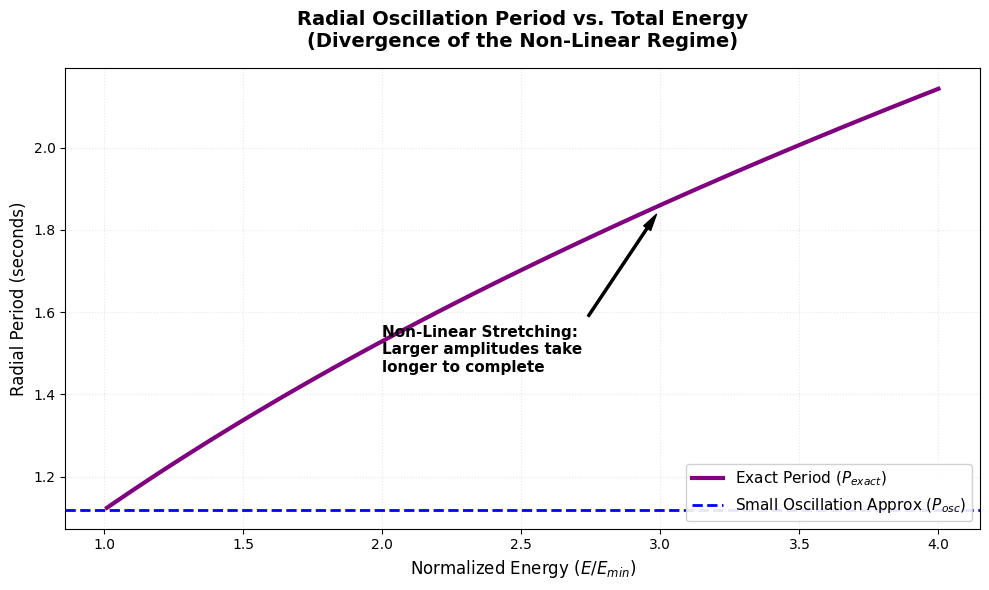

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

# ==========================================
# 1. System Parameters
# ==========================================
m1 = 1.0        # Mass of rotating disk (kg)
m2 = 1.0        # Mass of hanging object (kg)
g = 9.81        # Acceleration due to gravity (m/s^2)
L_ang = 1.0     # Conserved Angular Momentum (kg*m^2/s)

# ==========================================
# 2. Static Equilibrium & Small Oscillations
# ==========================================
# Calculate the equilibrium radius (r0) where dU_eff/dr = 0
r0 = (L_ang**2 / (m1 * m2 * g))**(1/3)

# The Minimum Effective Potential Energy (bottom of the well)
U_min = (L_ang**2) / (2 * m1 * r0**2) + m2 * g * r0

# Small Oscillation Period (Simple Harmonic Approximation)
P_small = 2 * np.pi * np.sqrt((m1 + m2) * r0 / (3 * m2 * g))

# ==========================================
# 3. Exact Large Oscillation Period
# ==========================================
def U_eff(r):
    """The Effective Potential Energy function"""
    return (L_ang**2) / (2 * m1 * r**2) + m2 * g * r

def integrand(r, E):
    """The function to integrate: 1 / sqrt(E - U_eff(r))"""
    val = E - U_eff(r)
    # Catch any floating point precision issues at the extreme boundaries
    if val <= 0:
        return 0.0
    return 1.0 / np.sqrt(val)

# Test an array of energy levels from just above U_min up to 4x U_min
E_vals = np.linspace(U_min * 1.01, U_min * 4.0, 100)
P_exact_vals = []

for E in E_vals:
    # Find turning points by solving the cubic: m2*g*r^3 - E*r^2 + L^2/(2*m1) = 0
    coeffs = [m2 * g, -E, 0, L_ang**2 / (2 * m1)]
    roots = np.roots(coeffs)

    # Filter for the physical bounds (positive real roots)
    real_roots = [np.real(r) for r in roots if np.isreal(r) and np.real(r) > 0]
    r_min, r_max = min(real_roots), max(real_roots)

    # Numerically integrate from r_min to r_max
    # quad automatically handles the integrable singularity at the endpoints
    res, error = quad(integrand, r_min, r_max, args=(E,))

    # Multiply by the sqrt(2*(m1+m2)) constant factor
    P_exact = np.sqrt(2 * (m1 + m2)) * res
    P_exact_vals.append(P_exact)

# ==========================================
# 4. Plotting the Comparison
# ==========================================
plt.figure(figsize=(10, 6))

# Plot both the exact period and the linear approximation
plt.plot(E_vals / U_min, P_exact_vals, 'purple', linewidth=3, label='Exact Period ($P_{exact}$)')
plt.axhline(P_small, color='blue', linestyle='--', linewidth=2, label='Small Oscillation Approx ($P_{osc}$)')

# Formatting and Annotations
plt.title("Radial Oscillation Period vs. Total Energy\n(Divergence of the Non-Linear Regime)", fontsize=14, pad=15, weight='bold')
plt.xlabel("Normalized Energy ($E / E_{min}$)", fontsize=12)
plt.ylabel("Radial Period (seconds)", fontsize=12)

# Point out where the approximation breaks down
plt.annotate('Non-Linear Stretching:\nLarger amplitudes take\nlonger to complete',
             xy=(3.0, P_exact_vals[-35]), xytext=(2.0, P_small * 1.3),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=6),
             fontsize=11, weight='bold')

plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle=':')

plt.tight_layout()
plt.show()